# Video Game Sales Prediction

## Veri Sözlüğü

- **Rank:** Satış sıralaması  
- **Name:** Oyun adı  
- **Platform:** Yayınlandığı platform  
- **Year:** Çıkış yılı  
- **Genre:** Oyun türü  
- **Publisher:** Yayıncı  
- **NA_Sales:** Kuzey Amerika satışları (milyon)  
- **EU_Sales:** Avrupa satışları (milyon)  
- **JP_Sales:** Japonya satışları (milyon)  
- **Other_Sales:** Diğer bölgeler (milyon)  
- **Global_Sales:** Toplam satış (milyon)

Bu projede video oyunlarının farklı bölgelerdeki satış verileri analiz edip  satışları tahmin edebilecek modeller geliştireceğiz. Amacımız oyunların satış performansını etkileyen faktörleri incelemek ve gelecekteki satışların yüksek doğrulukla tahmin edilmesini sağlamaktır.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from yellowbrick.regressor import ResidualsPlot
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.preprocessing import scale
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, InputLayer, Reshape, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf
from sklearn.pipeline import Pipeline
import os

In [2]:
df=pd.read_csv('vgsales.csv')

In [3]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


### EDA - Exploratory Data Analysis

Verinin yapısını , tipini ve sütun sayılarını kontrol ediyoruz.

In [4]:
df.shape

(16598, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [6]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


 - 1'e yakın: Güçlü pozitif korelasyon (birlikte artar)
 - -1'e yakın: Güçlü negatif korelasyon (biri artarken diğeri azalır)

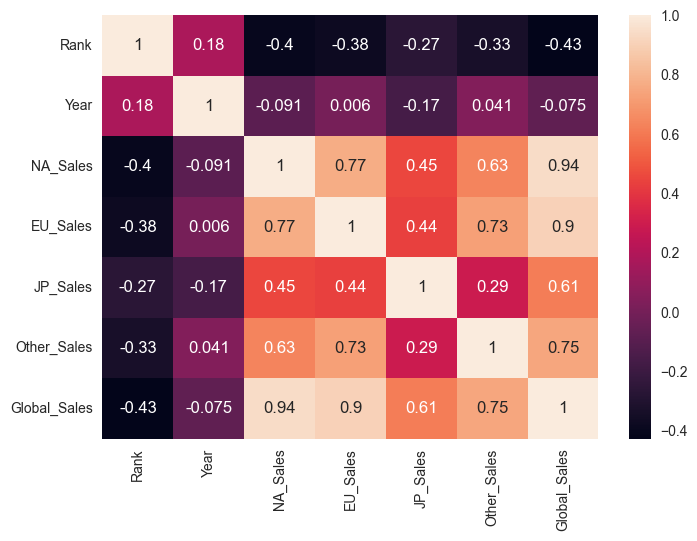

In [7]:
sns.heatmap(df.corr(numeric_only=True),annot=True);

Eksik değer var mı buna bakıyoruz.

In [8]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

Eksik değer olan tüm satırları siliyoruz.

In [9]:
df= df.dropna()

In [10]:
df.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [11]:
df['Rank'].unique()

array([    1,     2,     3, ..., 16598, 16599, 16600], shape=(16291,))

In [12]:
df['Name'].unique()

array(['Wii Sports', 'Super Mario Bros.', 'Mario Kart Wii', ...,
       'Plushees', 'Woody Woodpecker in Crazy Castle 5', 'Know How 2'],
      shape=(11325,), dtype=object)

In [13]:
df['Platform'].unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       '3DS', 'PS4', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne', 'GC',
       'WiiU', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

In [14]:
df['Genre'].unique()

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy'], dtype=object)

Genre sütununa göre gruplandırıp her türdeki oyun sayısını alıyoruz. Ve en çok satılan ilk 10 oyunu görüyoruz.

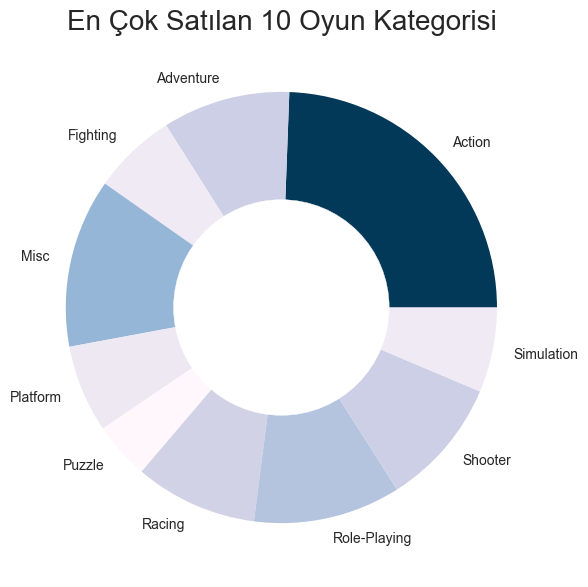

In [15]:
import matplotlib as mpl
game = df.groupby("Genre")["Global_Sales"].count().head(10)
custom_colors = mpl.colors.Normalize(vmin=min(game), vmax=max(game))
colours = [mpl.cm.PuBu(custom_colors(i)) for i in game]
plt.figure(figsize=(7,7))
plt.pie(game, labels=game.index, colors=colours)
central_circle = plt.Circle((0, 0), 0.5, color='white')
fig = plt.gcf()
fig.gca().add_artist(central_circle)
plt.rc('font', size=12)
plt.title("En Çok Satılan 10 Oyun Kategorisi", fontsize=20)
plt.show()

Hangi yıllarda çok oyun çıkarıldığını görselleştiriyoruz. En çok 2019-2010 civarında çok oyun satıldığını görüyoruz.

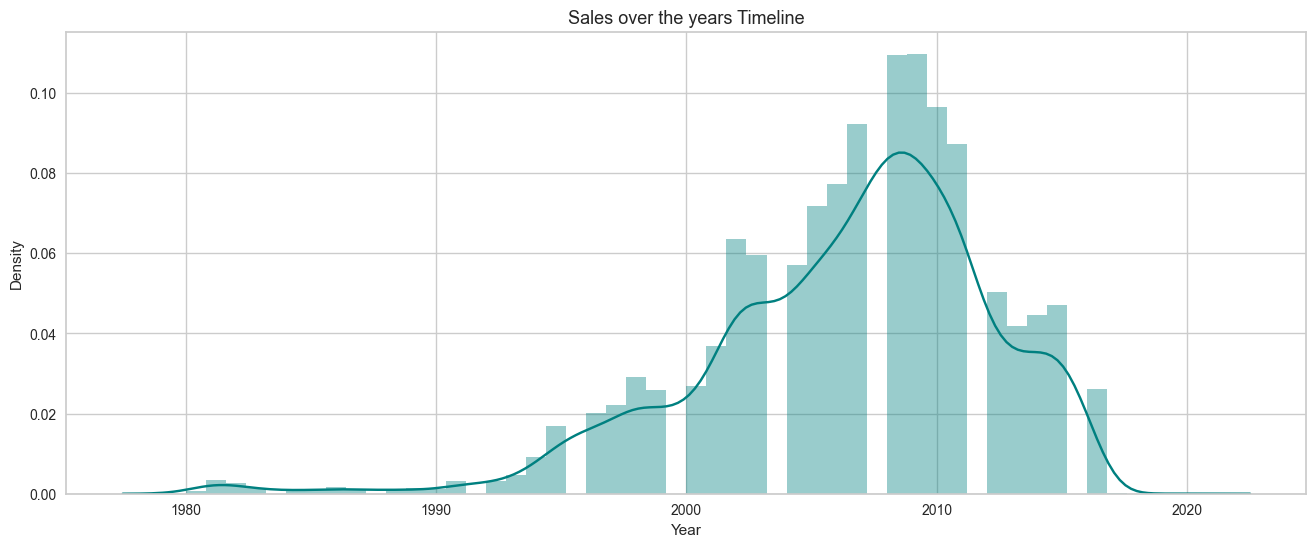

In [16]:
plt.figure(figsize=(16,6))
sns.distplot(df['Year'], color = 'teal')
plt.title('Sales over the years Timeline', size = 13)
plt.show()

Hangi platformun veri setinde en çok oyuna sahip olduğunu da inceleyelim.

Text(0.5, 1.0, 'Video games platforms representing frequency in the dataset')

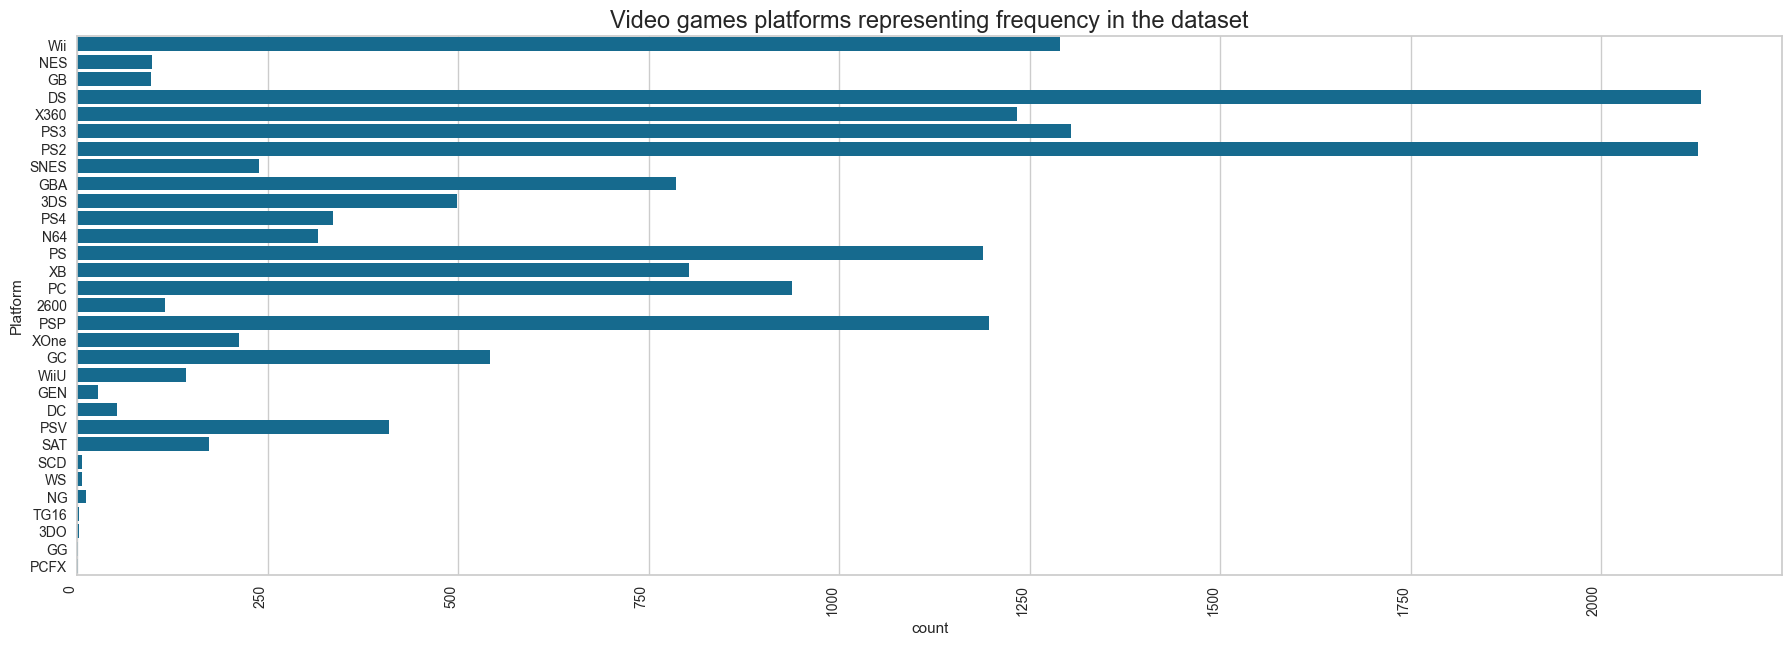

In [17]:
plt.figure(figsize=(22,7))
g =sns.countplot(df.Platform)
sns.set_context('notebook')
g.set_xticklabels(g.get_xticklabels(), rotation=90, ha="right")
plt.title("Video games platforms representing frequency in the dataset", size =17)

Genre, Platform, Publisher sütunları kategorik olduğu için bunları sayısal hale getiriyoruz.

In [18]:
df= pd.get_dummies(df, columns=['Genre','Platform','Publisher'], drop_first=True)

Name sütunu işimize yaramayacağı için onuda veri setimizden atıyoruz.

In [19]:
df=df.drop(['Name'], axis=1)

### Model Training & Testing

X ve Y değişkenlerini belirliyoruz.

In [20]:
x=df.drop('Global_Sales', axis=1)
y=df[['Global_Sales']]

In [21]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=.20, random_state=42)

Ve Linear Regressionla test etmeye başlıyoruz.

In [22]:
lr=LinearRegression()

In [23]:
model=lr.fit(x_train,y_train)

In [24]:
tahmin=model.predict(x_test)

Model performansımız çok yüksek çıkmış.Bu da modelin hedef değişkeni neredeyse mükemmele yakın açıkladığını gösterir.

In [25]:
r2_score(y_test,tahmin)

0.9999931572575395

In [26]:
mean_squared_error(y_test,tahmin)**.5

0.00541045576364854

In [27]:
karsilastirma=pd.DataFrame()

In [28]:
karsilastirma['gercekdeger']=y_test
karsilastirma['tahmin']=tahmin

In [29]:
karsilastirma

,gercekdeger,tahmin
3527,0.57,0.569857
12216,0.07,0.060735
7940,0.19,0.189897
3030,0.67,0.669969
7144,0.22,0.220418
...,...,...
13781,0.04,0.039792
15964,0.02,0.020110
11193,0.09,0.090279
9400,0.13,0.130599


In [30]:
residuals=y_test-tahmin 

In [31]:
residuals

,Global_Sales
3527,0.000143
12216,0.009265
7940,0.000103
3030,0.000031
7144,-0.000418
...,...
13781,0.000208
15964,-0.000110
11193,-0.000279
9400,-0.000599


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()

       
        
        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,kn,dt,xgb,svr,mlp_regressor]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','AdaBoost','Decision Tree','XGBRegressor','SVR','mlp_regressor']
        x=MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [33]:
algo_test(x,y)

,R_Squared,RMSE,MAE
Linear,0.999993,0.005410,0.003270
Ridge,0.981358,0.282401,0.077185
mlp_regressor,0.959441,0.416546,0.045076
Gradient Boosting,0.868714,0.749426,0.021177
Extra Tree,0.854521,0.788894,0.029629
Decision Tree,0.841138,0.824383,0.018291
KNeighborsRegressor,0.831872,0.848085,0.277805
XGBRegressor,0.803325,0.917261,0.043945
SGD,0.638710,1.243217,0.334734
SVR,0.369594,1.642212,0.243297


Genele bakacak olursak Linear model en iyi performansı göstermiş. Ridge ve MLP de Lineardan sonra iyi sonuç vermiş.

Burda da Derin Öğrenme ile tekrardan test ediyoruz.

In [34]:
scaler=StandardScaler()

In [35]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [36]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(84, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(54, activation='relu'))
model.add(Dense(44, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(14, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [37]:
history = model.fit(x_train, y_train,validation_split=0.2,epochs=50,batch_size=32)

Epoch 1/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2771 - mae: 0.2116 - val_loss: 0.1642 - val_mae: 0.1540
Epoch 2/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0579 - mae: 0.1138 - val_loss: 0.2634 - val_mae: 0.2412
Epoch 3/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0612 - mae: 0.1137 - val_loss: 0.0699 - val_mae: 0.0834
Epoch 4/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0276 - mae: 0.0744 - val_loss: 0.0252 - val_mae: 0.0677
Epoch 5/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0214 - mae: 0.0686 - val_loss: 0.0381 - val_mae: 0.0854
Epoch 6/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0537 - mae: 0.0808 - val_loss: 0.1765 - val_mae: 0.1740
Epoch 7/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0418 - mae: 0.0857 - val_loss: 0.0296 - val_mae: 0.0640
Epoch 8/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0288 - mae: 0.0675 - val_loss: 0.0299 - val_mae: 0.1013
Epoch 9/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - lo

In [38]:
model.save('videogame_sales_model.h5')

In [39]:
model.save('videogame_sales_model.keras')

In [40]:
model.evaluate(x_test, y_test)

102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0632 - mae: 0.0497


[0.06316231191158295, 0.049714792519807816]

In [41]:
y_pred = model.predict(x_test)
print("R2:", r2_score(y_test, y_pred))

102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
R2: 0.9852354526519775


Derin öğrenme ile test sonucu R² değerimiz 0.985 çıkmış. bu da modelin hedef değişkeni oldukça yüksek doğrulukla açıkladığını gösterir.

In [42]:
history_df = pd.DataFrame(history.history)
history_df.head()

,loss,mae,val_loss,val_mae
0,0.277103,0.211617,0.164159,0.154025
1,0.057860,0.113803,0.263415,0.241214
2,0.061213,0.113737,0.069948,0.083391
3,0.027552,0.074424,0.025216,0.067704
4,0.021427,0.068644,0.038109,0.085365


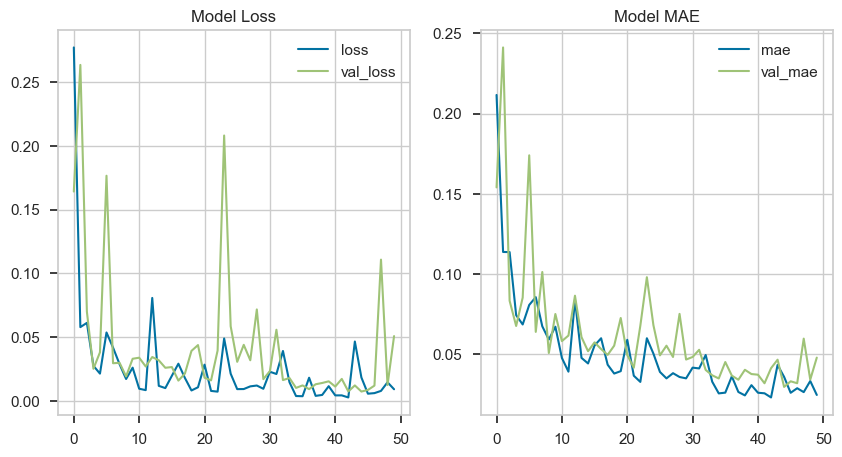

In [43]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(history_df['loss'], label='loss')
plt.plot(history_df['val_loss'], label='val_loss')
plt.title("Model Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_df['mae'], label='mae')
plt.plot(history_df['val_mae'], label='val_mae')
plt.title("Model MAE")
plt.legend()

plt.show()

Sonuç olarak, projemizi hem derin öğrenme modeliyle hem de klasik makine öğrenmesi yöntemleriyle test ettiğimizde %98’in üzerinde başarı elde ettiğimizi görüyoruz. Bu durum, modelimizin video oyunlarının satışlarını oldukça yüksek doğrulukla tahmin edebildiğini göstermektedir. Bu tür analizler sayesinde oyun sektörü, veriye dayalı olarak en çok satan oyunların özelliklerini inceleyebilir ve stratejilerini buna göre şekillendirerek satışlarını artırabilir.

tesekkürler :)